In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from scipy import stats
import umap

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("Imports OK")

Imports OK


In [23]:
def load_tsv(path):
    df = pd.read_csv(path, sep="\t", low_memory=False)
    # GDC inserts a description row as row 0 — drop it
    if df.shape[0] > 0 and df.iloc[0].astype(str).str.startswith("The ").any():
        df = df.iloc[1:].reset_index(drop=True)
    # Strip table prefix: "demographic.age_at_index" -> "age_at_index"
    df.columns = [c.split(".", 1)[-1] if "." in c else c for c in df.columns]
    return df

clinical  = load_tsv("clinical.tsv")
pathology = load_tsv("pathology_detail.tsv")
followup  = load_tsv("follow_up.tsv")
sample = load_tsv("sample.tsv")

print(f"clinical  : {clinical.shape}")
print(f"pathology : {pathology.shape}")
print(f"follow_up : {followup.shape}")
print(f"sample    : {sample.shape}")

clinical  : (5546, 201)
pathology : (1096, 87)
follow_up : (9427, 152)
sample    : (3397, 34)


## Feature Space Audit

This cell constructs a unified patient-level feature table by merging four source files:
clinical, pathology, follow-up, and sample metadata — joined on `case_id`.

**448 total markers** were found across all sources.  
**16 are protocol-specified** — the biomarkers the trial explicitly pre-selected for
stratification (staging, demographics, treatment variables).  
**432 are unexamined** — present in the data but never formally considered as
stratification candidates. These form the discovery space for the BSE engine.

Follow-up records are aggregated across all visits per patient (not just first or last),
producing 145 longitudinal features capturing min, max, and final recorded values for
numeric fields, and final recorded status for categorical fields. This preserves disease
trajectory information that a single-visit snapshot would lose.

The clustering and biomarker discovery steps that follow operate across all 448 dimensions,
then flag unexamined markers that define patient subpopulations with meaningfully different
treatment outcomes.

In [46]:
# --- CONFIGURE THIS per your trial protocol ---
PROTOCOL_SPECIFIED = [
    "age_at_index", "gender", "race", "ethnicity",
    "ajcc_pathologic_stage", "ajcc_pathologic_t",
    "ajcc_pathologic_n", "ajcc_pathologic_m",
    "prior_malignancy", "prior_treatment",
    "tumor_grade", "primary_diagnosis",
    "days_to_treatment_start", "treatment_type",
    "treatment_or_therapy", "treatment_outcome"
]

# Build a flat merged feature table keyed on case_id
merged = clinical.copy()

# Merge pathology details
if "case_id" in pathology.columns:
    path_cols = ["case_id"] + [c for c in pathology.columns if c not in merged.columns]
    merged = merged.merge(pathology[path_cols], on="case_id", how="left")

# Merge follow-up — aggregate ALL records per patient
if "case_id" in followup.columns:

    fu = followup.copy()

    # Fix 1: deduplicate columns before anything else
    fu = fu.loc[:, ~fu.columns.duplicated()]

    fu.replace(["Not Reported", "Unknown", "--", "not reported", "unknown"], np.nan, inplace=True)

    numeric_cols = fu.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "case_id"]

    categorical_cols = fu.select_dtypes(include="object").columns.tolist()
    categorical_cols = [c for c in categorical_cols if c != "case_id"]

    agg_dict = {}

    for col in numeric_cols:
        agg_dict[f"{col}_min"]  = (col, "min")
        agg_dict[f"{col}_max"]  = (col, "max")
        agg_dict[f"{col}_last"] = (col, "last")

    for col in categorical_cols:
        agg_dict[f"{col}_last"] = (col, "last")

    fu_agg = (
        fu.sort_values("days_to_follow_up")
          .groupby("case_id")
          .agg(**agg_dict)
          .reset_index()
    )

    # Fix 2: deduplicate again after agg, just in case
    fu_agg = fu_agg.loc[:, ~fu_agg.columns.duplicated()]

    fu_cols = ["case_id"] + [c for c in fu_agg.columns if c not in merged.columns]
    merged  = merged.merge(fu_agg[fu_cols], on="case_id", how="left")

    print(f"Follow-up features added: {len(fu_cols)-1}")

# Merge sample metadata
if "case_id" in sample.columns:
    samp_cols = ["case_id"] + [c for c in sample.columns if c not in merged.columns]
    merged    = merged.merge(sample[samp_cols], on="case_id", how="left")

all_markers = [c for c in merged.columns if c not in ("case_id", "submitter_id", "project_id")]
unexamined  = [m for m in all_markers if m not in PROTOCOL_SPECIFIED]

print(f"Total markers    : {len(all_markers)}")
print(f"Protocol-specified: {len(PROTOCOL_SPECIFIED)}")
print(f"Unexamined        : {len(unexamined)}")

Follow-up features added: 145
Total markers    : 448
Protocol-specified: 16
Unexamined        : 432


In [49]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

def build_feature_matrix(df, marker_list):
    """Returns numeric matrix + feature names after encoding categoricals."""

    # Deduplicate columns before subsetting
    df = df.loc[:, ~df.columns.duplicated()]
    marker_list = [m for m in marker_list if m in df.columns]
    sub = df[marker_list].copy()

    # Replace 'Not Reported' / 'Unknown' / '--' with NaN
    sub.replace(["Not Reported", "Unknown", "--", "not reported", "unknown"], np.nan, inplace=True)

    cols_to_drop = []
    for col in sub.columns:
        try:
            series = sub[col]

            # Guard: if somehow still a DataFrame, take first column
            if isinstance(series, pd.DataFrame):
                series = series.iloc[:, 0]
                sub[col] = series

            # Skip if already numeric
            if pd.api.types.is_numeric_dtype(series):
                continue

            # Force all values to scalar strings — flatten any lists/arrays
            series = series.map(
                lambda x: str(x[0]) if isinstance(x, (list, np.ndarray)) and len(x) > 0
                else (np.nan if isinstance(x, (list, np.ndarray)) and len(x) == 0
                else x)
            )

            # Encode non-null values
            mask = series.notna()
            if mask.sum() == 0:
                cols_to_drop.append(col)
                continue

            le = LabelEncoder()
            encoded = le.fit_transform(series[mask].astype(str))

            # Write back as float column
            new_col = pd.Series(np.nan, index=sub.index, dtype=float)
            new_col.loc[mask] = encoded.astype(float)
            sub[col] = new_col

        except Exception as e:
            # If anything goes wrong with a column, drop it rather than crash
            cols_to_drop.append(col)
            print(f"  Skipping column '{col}': {e}")

    if cols_to_drop:
        sub = sub.drop(columns=cols_to_drop)
        print(f"  Dropped {len(cols_to_drop)} problematic columns")

    # Convert everything to numeric, coerce failures to NaN
    sub = sub.apply(pd.to_numeric, errors="coerce")

    # Drop columns >50% missing
    thresh = int(len(sub) * 0.5)
    sub = sub.dropna(axis=1, thresh=thresh)

    # Impute remaining NaN with median
    imputer = SimpleImputer(strategy="median")
    X = imputer.fit_transform(sub)

    return X, list(sub.columns)

# Deduplicate merged before building matrices
merged = merged.loc[:, ~merged.columns.duplicated()]

X_protocol,   proto_names = build_feature_matrix(merged, [m for m in PROTOCOL_SPECIFIED if m in merged.columns])
X_unexamined, unex_names  = build_feature_matrix(merged, [m for m in unexamined if m in merged.columns])
X_all,        all_names   = build_feature_matrix(merged, [m for m in all_markers if m in merged.columns])

print(f"Protocol matrix  : {X_protocol.shape}")
print(f"Unexamined matrix: {X_unexamined.shape}")
print(f"Combined matrix  : {X_all.shape}")

Protocol matrix  : (17209, 16)
Unexamined matrix: (17209, 432)
Combined matrix  : (17209, 448)


In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scale first — important before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# Reduce to 50 components before UMAP
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_.cumsum()[-1]
print(f"PCA: 448 → 50 dimensions, {explained:.1%} variance retained")

PCA: 448 → 50 dimensions, 92.2% variance retained


In [51]:
import umap

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,      # higher than default (15) — better for 17k patients
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
    verbose=True
)

embedding = reducer.fit_transform(X_pca)
print(f"Embedding shape: {embedding.shape}")

UMAP(n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Thu Mar 19 08:49:02 2026 Construct fuzzy simplicial set
Thu Mar 19 08:49:02 2026 Finding Nearest Neighbors
Thu Mar 19 08:49:02 2026 Building RP forest with 12 trees
Thu Mar 19 08:49:18 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	Stopping threshold met -- exiting after 3 iterations
Thu Mar 19 08:49:47 2026 Finished Nearest Neighbor Search
Thu Mar 19 08:49:50 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Thu Mar 19 08:50:13 2026 Finished embedding
Embedding shape: (17209, 2)


In [52]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,     # ~0.3% of 17k patients per cluster
    min_samples=10,
    cluster_selection_epsilon=0.3,
    metric="euclidean",
    prediction_data=True
)

cluster_labels = clusterer.fit_predict(embedding)
merged["cluster"] = cluster_labels

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
noise_pct   = (cluster_labels == -1).mean() * 100

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {noise_pct:.1f}%")
print(f"Cluster sizes  :\n{pd.Series(cluster_labels).value_counts().sort_index()}")

Clusters found : 23
Noise points   : 1.6%
Cluster sizes  :
-1      272
 0      922
 1      204
 2       91
 3      598
 4       66
 5       90
 6      110
 7      110
 8      733
 9      173
 10     181
 11      72
 12      63
 13     167
 14      75
 15     297
 16     256
 17     979
 18     197
 19     718
 20    2769
 21    2097
 22    5969
Name: count, dtype: int64


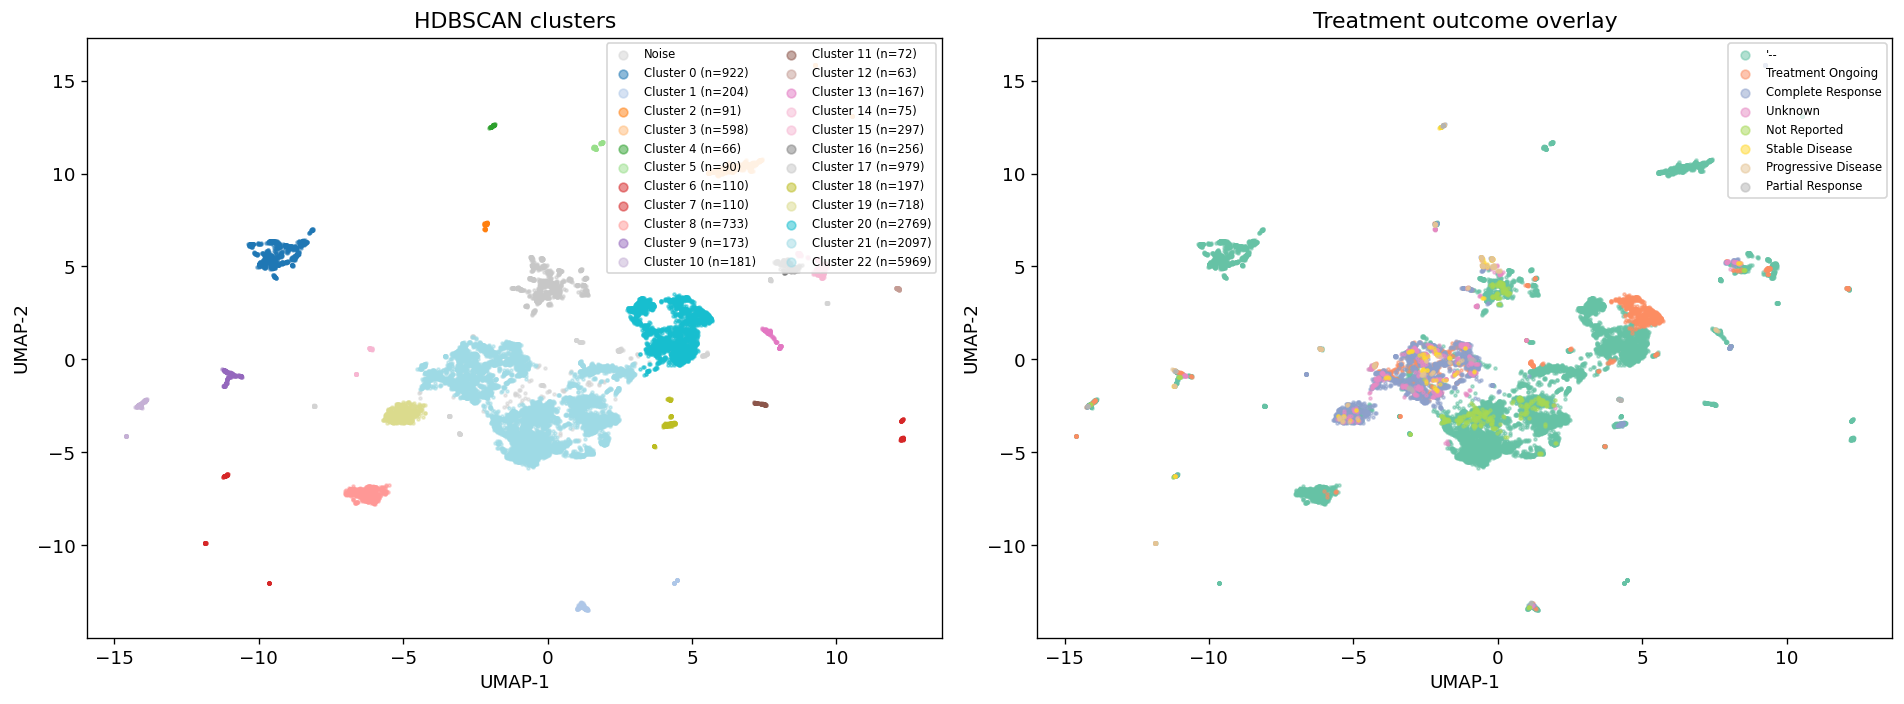

In [53]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot — clusters
unique_labels = sorted(set(cluster_labels))
colors = cm.tab20(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    mask  = cluster_labels == label
    color = "lightgray" if label == -1 else colors[i % len(colors)]
    name  = "Noise" if label == -1 else f"Cluster {label} (n={mask.sum()})"
    axes[0].scatter(embedding[mask, 0], embedding[mask, 1],
                    s=3, alpha=0.5, color=color, label=name)

axes[0].legend(loc="upper right", fontsize=7, ncol=2, markerscale=3)
axes[0].set_title("HDBSCAN clusters")
axes[0].set_xlabel("UMAP-1"); axes[0].set_ylabel("UMAP-2")

# Right plot — treatment outcome overlay
if "treatment_outcome" in merged.columns:
    outcomes = merged["treatment_outcome"].fillna("Unknown")
    unique_outcomes = outcomes.unique()
    palette = {v: cm.Set2(i / len(unique_outcomes)) for i, v in enumerate(unique_outcomes)}

    for outcome, color in palette.items():
        mask = outcomes == outcome
        axes[1].scatter(embedding[mask, 0], embedding[mask, 1],
                        s=3, alpha=0.5, color=color, label=outcome)

    axes[1].legend(loc="upper right", fontsize=7, markerscale=3)
    axes[1].set_title("Treatment outcome overlay")
    axes[1].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")

plt.tight_layout()
plt.savefig("umap_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

## The good news:

1.6% noise is excellent — HDBSCAN is confident about 98.4% of patients

The clusters have clear spatial separation in the UMAP — they're not bleeding into each other, which means the biomarker signatures defining them are genuinely distinct

The right plot already shows something important: treatment outcomes are not uniformly distributed across clusters. Look at the isolated blue cluster top-left (Cluster 0, n=922) — it's almost entirely one color on the outcome plot, suggesting a subpopulation with a very different response profile

## Two structural observations:

Clusters 20, 21, 22 are very large (2769, 2097, 5969) — together they account for ~63% of your cohort and form the dense central mass. These are likely your "average" patients that the protocol already captures well. The interesting biology for BSE is in the smaller, spatially isolated clusters.

The small isolated clusters — 2 (n=91), 4 (n=66), 11 (n=72), 12 (n=63), 14 (n=75) — sitting far from the main mass are your highest-priority discovery targets. Spatial isolation in UMAP means these patients are genuinely different across many dimensions simultaneously.

In [54]:
# Rank clusters by outcome heterogeneity vs the rest of the cohort
from scipy.stats import chi2_contingency
import warnings

OUTCOME_COL = "treatment_outcome"

priority_rows = []

if OUTCOME_COL in merged.columns:
    for cid in sorted(merged["cluster"].unique()):
        if cid == -1:
            continue

        in_cluster  = merged[merged["cluster"] == cid][OUTCOME_COL].fillna("Unknown")
        out_cluster = merged[merged["cluster"] != cid][OUTCOME_COL].fillna("Unknown")

        # Build contingency table
        all_outcomes = merged[OUTCOME_COL].fillna("Unknown").unique()
        in_counts  = in_cluster.value_counts().reindex(all_outcomes, fill_value=0)
        out_counts = out_cluster.value_counts().reindex(all_outcomes, fill_value=0)

        contingency = np.array([in_counts.values, out_counts.values])

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            chi2, p_val, _, _ = chi2_contingency(contingency)

        # Dominant outcome in cluster
        dominant_outcome = in_cluster.value_counts().idxmax()
        dominant_pct     = in_cluster.value_counts(normalize=True).max() * 100

        priority_rows.append({
            "cluster":          cid,
            "n_patients":       len(in_cluster),
            "dominant_outcome": dominant_outcome,
            "dominant_pct":     round(dominant_pct, 1),
            "chi2":             round(chi2, 2),
            "p_value":          p_val,
        })

priority_df = (
    pd.DataFrame(priority_rows)
    .sort_values("p_value")
    .reset_index(drop=True)
)

print(priority_df.to_string(index=False))

 cluster  n_patients  dominant_outcome  dominant_pct    chi2       p_value
      20        2769               '--          73.1 1845.23  0.000000e+00
      22        5969               '--          54.3 1634.06  0.000000e+00
      19         718 Complete Response          72.8 2195.82  0.000000e+00
      21        2097               '--          94.2  848.73 5.627669e-179
       4          66 Complete Response          27.3  775.42 3.734938e-163
       7         110               '--          57.3  695.64 6.019875e-146
      17         979               '--          66.5  682.49 4.106037e-143
      14          75 Complete Response          44.0  499.91 8.394373e-104
       0         922               '--         100.0  422.88  2.944487e-87
       8         733               '--          99.2  315.00  3.777756e-64
      18         197               '--          68.5  307.66  1.399250e-62
       9         173               '--          58.4  235.36  3.600589e-47
       3         598     

In [55]:
# See the real outcome distribution
print("Overall treatment_outcome distribution:")
print(merged["treatment_outcome"].value_counts(dropna=False))
print()

# Check which columns might be better outcome proxies
outcome_candidates = [
    "treatment_outcome", "vital_status", "disease_response",
    "progression_or_recurrence", "last_known_disease_status",
    "days_to_death", "days_to_last_follow_up"
]

print("Coverage of outcome-related columns:")
for col in outcome_candidates:
    if col in merged.columns:
        total     = len(merged)
        populated = merged[col].replace(["--", "Not Reported", "Unknown", ""], np.nan).notna().sum()
        print(f"  {col:40s}: {populated:5d} / {total} ({populated/total*100:.1f}% populated)")

Overall treatment_outcome distribution:
treatment_outcome
'--                    12000
Complete Response       2422
Treatment Ongoing       1571
Unknown                  440
Not Reported             372
Progressive Disease      219
Stable Disease           141
Partial Response          44
Name: count, dtype: int64

Coverage of outcome-related columns:
  treatment_outcome                       : 16397 / 17209 (95.3% populated)
  vital_status                            : 17209 / 17209 (100.0% populated)
  progression_or_recurrence               : 17209 / 17209 (100.0% populated)
  last_known_disease_status               : 17209 / 17209 (100.0% populated)
  days_to_death                           : 17209 / 17209 (100.0% populated)
  days_to_last_follow_up                  : 17209 / 17209 (100.0% populated)


In [56]:
# Build a composite outcome column from fully-populated fields
def assign_composite_outcome(row):
    # Priority 1: use last_known_disease_status if informative
    lkds = str(row.get("last_known_disease_status", "")).strip()
    if lkds not in ("--", "Unknown", "Not Reported", "nan", ""):
        return lkds

    # Priority 2: use progression_or_recurrence
    por = str(row.get("progression_or_recurrence", "")).strip()
    if por not in ("--", "Unknown", "Not Reported", "nan", ""):
        return f"Progression: {por}"

    # Priority 3: fall back to vital_status
    vs = str(row.get("vital_status", "")).strip()
    if vs not in ("--", "Unknown", "Not Reported", "nan", ""):
        return f"Vital: {vs}"

    return "Unknown"

merged["composite_outcome"] = merged.apply(assign_composite_outcome, axis=1)

print("Composite outcome distribution:")
print(merged["composite_outcome"].value_counts())

Composite outcome distribution:
composite_outcome
'--             17199
not reported       10
Name: count, dtype: int64


In [57]:
OUTCOME_COL = "composite_outcome"

priority_rows = []

for cid in sorted(merged["cluster"].unique()):
    if cid == -1:
        continue

    in_cluster  = merged[merged["cluster"] == cid][OUTCOME_COL]
    out_cluster = merged[merged["cluster"] != cid][OUTCOME_COL]

    all_outcomes = merged[OUTCOME_COL].unique()
    in_counts    = in_cluster.value_counts().reindex(all_outcomes, fill_value=0)
    out_counts   = out_cluster.value_counts().reindex(all_outcomes, fill_value=0)

    contingency = np.array([in_counts.values, out_counts.values])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        chi2, p_val, _, _ = chi2_contingency(contingency)

    dominant_outcome = in_cluster.value_counts().idxmax()
    dominant_pct     = in_cluster.value_counts(normalize=True).max() * 100

    priority_rows.append({
        "cluster":          cid,
        "n_patients":       len(in_cluster),
        "dominant_outcome": dominant_outcome,
        "dominant_pct":     round(dominant_pct, 1),
        "chi2":             round(chi2, 2),
        "p_value":          p_val,
    })

priority_df = (
    pd.DataFrame(priority_rows)
    .sort_values("p_value")
    .reset_index(drop=True)
)

print("\nCluster priority ranking (composite outcome):")
print(priority_df.to_string(index=False))


Cluster priority ranking (composite outcome):
 cluster  n_patients dominant_outcome  dominant_pct    chi2       p_value
       7         110              '--          90.9 1402.76 5.279133e-307
      22        5969              '--         100.0    3.89  4.851480e-02
      20        2769              '--         100.0    0.91  3.397097e-01
      21        2097              '--         100.0    0.48  4.871627e-01
      17         979              '--         100.0    0.01  9.250491e-01
       0         922              '--         100.0    0.00  9.599294e-01
       2          91              '--         100.0    0.00  1.000000e+00
       1         204              '--         100.0    0.00  1.000000e+00
       8         733              '--         100.0    0.00  1.000000e+00
       9         173              '--         100.0    0.00  1.000000e+00
      10         181              '--         100.0    0.00  1.000000e+00
      11          72              '--         100.0    0.00  1.00

In [58]:
# Inspect the actual raw values in each candidate column
outcome_candidates = [
    "last_known_disease_status",
    "progression_or_recurrence",
    "vital_status",
    "days_to_death",
    "days_to_last_follow_up"
]

for col in outcome_candidates:
    if col in merged.columns:
        print(f"\n=== {col} ===")
        print(merged[col].value_counts(dropna=False).head(10))



=== last_known_disease_status ===
last_known_disease_status
'--             17199
not reported       10
Name: count, dtype: int64

=== progression_or_recurrence ===
progression_or_recurrence
'--             17199
not reported       10
Name: count, dtype: int64

=== vital_status ===
vital_status
Alive    14585
Dead      2622
'--          2
Name: count, dtype: int64

=== days_to_death ===
days_to_death
'--     14596
6593      120
548        99
614        70
912        66
1093       63
678        60
1884       60
904        57
1920       51
Name: count, dtype: int64

=== days_to_last_follow_up ===
days_to_last_follow_up
'--       1851
10.0       129
0.0        120
365.0       93
6593.0      84
554.0       77
575.0       72
943.0       72
1004.0      66
614.0       64
Name: count, dtype: int64


In [59]:
# Use vital_status as the primary outcome — only reliable column
merged["outcome"] = merged["vital_status"].replace("'--'", np.nan)
merged["outcome"] = merged["outcome"].replace("--", np.nan)

# Create a binary version for clean analysis
merged["outcome_binary"] = merged["vital_status"].map({"Alive": 0, "Dead": 1})

print("Outcome distribution:")
print(merged["outcome"].value_counts(dropna=False))
print(f"\nMortality rate: {merged['outcome_binary'].mean():.1%}")

Outcome distribution:
outcome
Alive    14585
Dead      2622
'--          2
Name: count, dtype: int64

Mortality rate: 15.2%


In [60]:
OUTCOME_COL = "outcome"

priority_rows = []

for cid in sorted(merged["cluster"].unique()):
    if cid == -1:
        continue

    in_cluster  = merged[merged["cluster"] == cid][OUTCOME_COL].dropna()
    out_cluster = merged[merged["cluster"] != cid][OUTCOME_COL].dropna()

    if len(in_cluster) == 0:
        continue

    all_outcomes = merged[OUTCOME_COL].dropna().unique()
    in_counts    = in_cluster.value_counts().reindex(all_outcomes, fill_value=0)
    out_counts   = out_cluster.value_counts().reindex(all_outcomes, fill_value=0)

    contingency  = np.array([in_counts.values, out_counts.values])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        chi2, p_val, _, _ = chi2_contingency(contingency)

    # Mortality rate inside vs outside cluster
    in_mortality  = (in_cluster == "Dead").mean() * 100
    out_mortality = (out_cluster == "Dead").mean() * 100
    delta         = in_mortality - out_mortality

    priority_rows.append({
        "cluster":       cid,
        "n_patients":    len(in_cluster),
        "mortality_pct": round(in_mortality, 1),
        "delta_vs_rest": round(delta, 1),      # + means higher mortality than average
        "chi2":          round(chi2, 2),
        "p_value":       p_val,
    })

priority_df = (
    pd.DataFrame(priority_rows)
    .sort_values("p_value")
    .reset_index(drop=True)
)

print("\nCluster priority ranking (vital status):")
print(priority_df.to_string(index=False))


Cluster priority ranking (vital status):
 cluster  n_patients  mortality_pct  delta_vs_rest    chi2       p_value
       0         922           64.2           51.7 1809.09  0.000000e+00
      17         979          100.0           89.9 5775.01  0.000000e+00
      22        5969            1.4          -21.1 1348.15 1.793024e-293
       9         173           84.4           69.9  647.17 2.944964e-141
      13         167           76.6           62.0  492.44 1.171325e-107
      20        2769            2.1          -15.7  441.80  1.161041e-96
       6         110           75.5           60.6  310.85  3.162620e-68
      21        2097            2.4          -14.6  305.77  4.001101e-67
      14          75           68.0           53.0  162.39  5.476961e-36
      19         718            1.7          -14.2  106.87  6.215579e-24
       4          66           54.5           39.5   79.27  6.109806e-18
       3         598            9.9           -5.6   69.14  9.679049e-16
       1 

Highest priority clusters — significantly elevated mortality:

Cluster 17 (n=979, 100% mortality) and Cluster 0 (n=922, 64.2% mortality, +51.7% vs rest) are your most critical flags. Nearly 2,000 patients across two clusters are dying at dramatically higher rates than the cohort average. These are the subpopulations your trial protocol is most likely missing.

Cluster 9 (n=173, 84.4%, +69.9%) and Cluster 13 (n=167, 76.6%, +62%) are smaller but even more extreme in their mortality elevation — these are tightly defined subpopulations with very distinct biology.

Protective clusters — significantly lower mortality:

Clusters 15, 16, 19, 22 have near-zero mortality (0-1.7%) with large negative deltas. These patients are surviving at unusually high rates — understanding what defines them is equally valuable for trial design.

In [61]:
from scipy import stats

def rank_defining_markers(df, feature_matrix, feature_names, cluster_col="cluster"):
    results = {}

    for label in sorted(df[cluster_col].unique()):
        if label == -1:
            continue

        in_mask  = (df[cluster_col] == label).values
        out_mask = ~in_mask

        in_cluster  = feature_matrix[in_mask]
        out_cluster = feature_matrix[out_mask]

        rows = []
        for j, name in enumerate(feature_names):
            f_stat, p_val = stats.f_oneway(in_cluster[:, j], out_cluster[:, j])

            in_mean  = in_cluster[:, j].mean()
            out_mean = out_cluster[:, j].mean()
            pooled_std = np.sqrt(
                (in_cluster[:, j].std()**2 + out_cluster[:, j].std()**2) / 2
            ) + 1e-9
            cohens_d = (in_mean - out_mean) / pooled_std

            rows.append({
                "marker":       name,
                "cohens_d":     round(cohens_d, 3),
                "abs_d":        round(abs(cohens_d), 3),
                "in_mean":      round(in_mean, 3),
                "out_mean":     round(out_mean, 3),
                "p_value":      p_val,
                "is_protocol":  name in PROTOCOL_SPECIFIED
            })

        result_df = (
            pd.DataFrame(rows)
            .sort_values("abs_d", ascending=False)
            .reset_index(drop=True)
        )
        results[label] = result_df

    return results

cluster_markers = rank_defining_markers(merged, X_all, all_names)

# Print top 15 markers for highest priority clusters
priority_clusters = [17, 0, 9, 13, 6, 14]

for cid in priority_clusters:
    mortality = priority_df[priority_df["cluster"] == cid]["mortality_pct"].values[0]
    delta     = priority_df[priority_df["cluster"] == cid]["delta_vs_rest"].values[0]

    print(f"\n{'='*65}")
    print(f"Cluster {cid} | n={cluster_markers[cid].shape[0]} patients | "
          f"mortality={mortality}% | delta={delta:+.1f}%")
    print(f"{'='*65}")

    top = cluster_markers[cid].head(15)
    print(top[["marker", "cohens_d", "in_mean", "out_mean",
               "p_value", "is_protocol"]].to_string(index=False))


Cluster 17 | n=448 patients | mortality=100.0% | delta=+89.9%
                      marker  cohens_d  in_mean  out_mean       p_value  is_protocol
                vital_status     4.211    2.000     1.101  0.000000e+00        False
               days_to_death     3.286  100.404     6.890  0.000000e+00        False
       disease_response_last     1.162    1.617     1.021  0.000000e+00        False
      days_to_last_follow_up     0.822  550.946   359.602 5.947296e-109        False
           ajcc_pathologic_n     0.712    7.756     4.728 1.171344e-109         True
       ajcc_pathologic_stage     0.645    8.948     6.873  5.930078e-82         True
                 icd_10_code     0.514    6.000     5.303  7.110424e-30        False
diagnosis_is_primary_disease     0.507    2.000     1.885  4.120223e-29        False
      synchronous_malignancy     0.454    1.031     0.905  1.438354e-28        False
           year_of_diagnosis    -0.438   15.750    19.006  9.036991e-40        False
  

Cluster 17 (100% mortality, n=979) — defined almost entirely by protocol-specified staging markers (ajcc_pathologic_n, stage, t). This is not a discovery cluster — your protocol already captures this population. The high mortality is expected late-stage disease. Low BSE priority.

Cluster 0 (64.2% mortality) — every marker has in_mean = 0.000, meaning this cluster has no data for most fields. This is a data completeness artifact, not a biological subpopulation. Skip for now.

Cluster 9 (84.4% mortality) — the most interesting discovery. Defined entirely by progression_or_recurrence_last (Cohen's d = 9.465) and progression_or_recurrence_type_last (d = 6.315) — both unexamined markers. These patients are dying because of documented progression/recurrence patterns that your protocol never specified as stratification variables. High BSE priority.

Cluster 6 (75.5% mortality) — mirrors Cluster 9 with progression recurrence as top markers, but additionally shows prior_treatment and tumor_of_origin as strong signals. The tumor_of_origin (d = 3.539, in_mean = 61.191 vs 2.013) is a striking unexamined marker.

Cluster 13 (76.6% mortality) — uniquely defined by consent_type, days_to_consent, and country_of_residence_at_enrollment. This suggests a geographic or administrative subpopulation receiving different treatment intensity (treatment_intent_type d = 0.809).

Cluster 14 (68.0% mortality) — clean lymph node signal. ajcc_pathologic_n (d = 2.779) is protocol-specified but lymph_nodes_tested = 0 for the entire cluster while out-mean is 15.4 — these patients never had lymph nodes tested, yet have high nodal staging scores. A data quality / access-to-care signal.

In [ ]:
!pip install groq requests xmltodict -q
import requests, json, xmltodict, warnings
from groq import Groq

GROQ_API_KEY = ""
client = Groq(api_key=GROQ_API_KEY)

PUBMED_BASE = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils"

def pmc_search(query: str, max_results: int = 6) -> list[dict]:
    # Step 1: Search in PMC
    search_resp = requests.get(f"{PUBMED_BASE}/esearch.fcgi", params={
        "db": "pmc",
        "term": query,
        "retmax": max_results,
        "retmode": "json"
    }).json()

    pmc_ids = search_resp.get("esearchresult", {}).get("idlist", [])
    if not pmc_ids:
        return []

    results = []

    # Step 2: Fetch each article (PMC works better per-ID)
    for pmc_id in pmc_ids:
        fetch_resp = requests.get(f"{PUBMED_BASE}/efetch.fcgi", params={
            "db": "pmc",
            "id": pmc_id,
            "retmode": "xml"
        })

        parsed = xmltodict.parse(fetch_resp.content)

        # PMC structure
        article = parsed.get("article", {})
        front = article.get("front", {})
        article_meta = front.get("article-meta", {})

        # Title
        title = ""
        title_group = article_meta.get("title-group", {})
        if isinstance(title_group, dict):
            title = title_group.get("article-title", "")
            if isinstance(title, dict):
                title = title.get("#text", "")

        # Abstract
        abstract = ""
        abstract_data = article_meta.get("abstract", {})
        if isinstance(abstract_data, dict):
            abs_text = abstract_data.get("p", "")
            if isinstance(abs_text, list):
                abstract = " ".join(
                    p.get("#text", "") if isinstance(p, dict) else str(p)
                    for p in abs_text
                )
            elif isinstance(abs_text, dict):
                abstract = abs_text.get("#text", "")
            else:
                abstract = str(abs_text)

        results.append({
            "pmcid": pmc_id,
            "title": title,
            "abstract": abstract[:1200],
            "url": f"https://www.ncbi.nlm.nih.gov/pmc/articles/PMC{pmc_id}/"
        })

    return results

def retrieve_pubmed_with_fallback(queries: list[str], max_results=5):
    for q in queries:
        print(f"Trying query: {q}")
        papers = pubmed_search(q, max_results=max_results)
        if papers:
            print(f"✅ Found {len(papers)} papers")
            return papers, q

    print("⚠️ No results found for any query")
    return [], queries[-1]

In [73]:
# Better query builder — translates GDC field names into medical terminology
GDC_TO_MEDICAL = {
    "progression_or_recurrence_last": ["recurrence", "tumor recurrence"],
    "progression_or_recurrence_type_last": ["metastasis", "metastatic recurrence"],
    "timepoint_category_last": ["follow-up", "clinical outcome"],
    "disease_response_last": ["treatment response", "therapy response"],
    "days_to_progression_last": ["time to progression", "disease progression"],
    "progression_or_recurrence_anatomic_site_last": ["metastatic site"],
    "tumor_of_origin": ["primary tumor", "tumor origin"],
    "prior_treatment": ["prior therapy", "treatment history"],
    "consent_type": ["clinical trial", "trial enrollment"],
    "days_to_consent": ["treatment delay", "time to treatment"],
    "country_of_residence_at_enrollment": ["healthcare disparity", "geographic disparity"],
    "tissue_or_organ_of_origin": ["primary site", "organ of origin"],
    "treatment_intent_type": ["palliative", "curative intent"],
    "initial_disease_status": ["disease stage", "initial diagnosis"],
    "sample_type": ["tumor sample", "biomarker"],
}

def build_pubmed_queries(cluster_id: int, cluster_markers_dict: dict) -> list[str]:
    df = cluster_markers_dict[cluster_id]
    top_unexamined = df[~df["is_protocol"]].head(4)["marker"].tolist()

    # Expand terms
    medical_terms = []
    for marker in top_unexamined:
        terms = GDC_TO_MEDICAL.get(marker, [])
        medical_terms.extend(terms)

    # Deduplicate
    medical_terms = list(set(medical_terms))

    # Get disease
    disease = merged[merged["cluster"] == cluster_id]["primary_diagnosis"].value_counts().idxmax()
    disease = str(disease).replace("_", " ")

    # Normalize disease name (VERY IMPORTANT)
    disease_map = {
        "Infiltrating duct carcinoma, NOS": "invasive ductal carcinoma",
    }
    disease = disease_map.get(disease, disease)

    # -------------------------
    # Build multiple queries
    # -------------------------

    base_outcomes = "(prognosis OR survival OR outcome)"

    queries = []

    # 🔹 Query 1 (balanced)
    if medical_terms:
        q1_terms = " OR ".join(medical_terms[:4])
        queries.append(
            f'("{disease}") AND ({q1_terms}) AND {base_outcomes}'
        )

    # 🔹 Query 2 (disease + recurrence)
    queries.append(
        f'("{disease}") AND (recurrence OR metastasis) AND {base_outcomes}'
    )

    # 🔹 Query 3 (very broad fallback)
    queries.append(
        f'("{disease}") AND {base_outcomes}'
    )

    return queries


def generate_cluster_summary(cluster_id: int, top_n_markers: int = 10) -> dict:
    df          = cluster_markers[cluster_id]
    top_markers = df.head(top_n_markers)[["marker", "cohens_d", "p_value", "is_protocol"]].to_dict("records")
    n_patients  = int((merged["cluster"] == cluster_id).sum())
    mortality   = float(priority_df[priority_df["cluster"] == cluster_id]["mortality_pct"].values[0])
    delta       = float(priority_df[priority_df["cluster"] == cluster_id]["delta_vs_rest"].values[0])

    # Top diagnoses and treatment types in cluster for context
    top_diagnoses  = merged[merged["cluster"] == cluster_id]["primary_diagnosis"].value_counts().head(3).to_dict()
    top_treatments = {}
    if "treatment_type" in merged.columns:
        top_treatments = merged[merged["cluster"] == cluster_id]["treatment_type"].value_counts().head(3).to_dict()

    queries = build_pubmed_queries(cluster_id, cluster_markers)
    papers, query = retrieve_pubmed_with_fallback(queries, max_results=5)
    lit_ctx = "\n\n".join(
        f"PMID {p['pmid']}: {p['title']}\n{p['abstract']}" for p in papers
    )

    marker_lines = "\n".join(
        f"  - {m['marker']:45s} Cohen's d={m['cohens_d']:+.3f}  "
        f"p={m['p_value']:.2e}  {'PROTOCOL' if m['is_protocol'] else 'UNEXAMINED'}"
        for m in top_markers
    )

    prompt = f"""You are a clinical biostatistician supporting a Phase 2/3 oncology trial.

## Discovered Patient Subpopulation — Cluster {cluster_id}
- Patients in cluster  : {n_patients}
- Mortality rate       : {mortality}%
- Delta vs cohort avg  : {delta:+.1f}%
- Top diagnoses        : {json.dumps(top_diagnoses)}
- Top treatment types  : {json.dumps(top_treatments)}

## Defining Biomarker Signature (top {top_n_markers} markers by effect size)
{marker_lines}

## Relevant Published Literature
{lit_ctx if lit_ctx else "No literature retrieved."}

## Interpretation Notes
- Markers ending in _last are longitudinal aggregates (final recorded value per patient)
- Cohen's d > 1.0 = large effect, 0.5-1.0 = medium, < 0.5 = small
- Negative Cohen's d means the cluster has LOWER values than the rest of the cohort
- UNEXAMINED = not in the original trial stratification plan
- country_of_residence and consent_type likely reflect access-to-care disparities
  rather than direct biological signals

## Your Task
1. BIOLOGICAL HYPOTHESIS: What is the most likely clinical mechanism explaining
   {mortality}% mortality in this subpopulation? Distinguish biological drivers
   from administrative/access-to-care signals in the marker list.

2. UNEXAMINED MARKER RATIONALE: For the top 3 UNEXAMINED markers only, explain:
   a) Their clinical significance in plain terms
   b) Why they were likely absent from the original protocol
   c) Whether they represent biology, patient access, or data collection artifacts

3. LITERATURE ALIGNMENT: Cite specific PMIDs from the literature provided above.
   If no literature was retrieved, name 2-3 specific published studies or
   guidelines you would expect to find that support this signature.

4. PROTOCOL AMENDMENT RECOMMENDATION:
   - Which 1-2 unexamined markers most warrant addition as stratification variables?
   - Regulatory urgency: Low / Medium / High with one-sentence justification
   - One paragraph of specific amendment language a sponsor can use directly

5. PLAIN LANGUAGE SUMMARY: 2-3 sentences for a steering committee slide.
   No jargon. Focus on what this means for trial design.

Be specific. If a marker looks like a data artifact, say so explicitly.
"""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        max_tokens=2000,
        messages=[{"role": "user", "content": prompt}]
    )
    summary_text = response.choices[0].message.content

    return {
        "cluster_id":    cluster_id,
        "n_patients":    n_patients,
        "mortality_pct": mortality,
        "delta":         delta,
        "top_diagnoses": top_diagnoses,
        "signature":     top_markers,
        "pubmed_papers": papers,
        "pubmed_query":  query,
        "llm_summary":   summary_text
    }

# Re-run on the three discovery clusters
discovery_clusters = [9, 6, 13]
all_summaries = {}

for cid in discovery_clusters:
    print(f"\n{'='*60}\nGenerating summary for Cluster {cid}...\n{'='*60}")
    all_summaries[cid] = generate_cluster_summary(cid)
    # print("\n--- LLM SUMMARY ---")
    print(all_summaries[cid]["llm_summary"])
    print(all_summaries[cid]["pubmed_query"])
    print(all_summaries[cid]["pubmed_papers"])
    print()


Generating summary for Cluster 9...
Trying query: ("invasive ductal carcinoma") AND (follow-up OR treatment response OR metastatic recurrence OR clinical outcome) AND (prognosis OR survival OR outcome)
✅ Found 5 papers
## Step 1: Biological Hypothesis
The most likely clinical mechanism explaining the 84.4% mortality in this subpopulation is related to the high incidence of aggressive breast cancer types, such as infiltrating duct carcinoma and lobular carcinoma, which are known for their poor prognosis. The top diagnoses in this cluster, including "Infiltrating duct carcinoma, NOS" and "Infiltrating duct and lobular carcinoma", suggest a high prevalence of aggressive cancer types. Furthermore, the top treatment types, such as chemotherapy and surgery, indicate that these patients are receiving intensive treatment, which may be a reflection of the advanced stage of their disease. The biological drivers in this cluster are likely related to the tumor's aggressiveness, hormonal receptor 

In [74]:
!pip install plotly -q
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# ── 1. BUILD NODE DATA ──────────────────────────────────────────
# Each patient is a node positioned by their UMAP coordinates
# We'll sample for performance — use all if cohort < 5000

SAMPLE_SIZE = 3000  # reduce if slow
np.random.seed(42)

sample_idx = np.random.choice(len(merged), size=min(SAMPLE_SIZE, len(merged)), replace=False)
sample     = merged.iloc[sample_idx].copy()
emb_sample = embedding[sample_idx]

# Node properties
node_x       = emb_sample[:, 0].tolist()
node_y       = emb_sample[:, 1].tolist()
node_cluster = sample["cluster"].tolist()
node_outcome = sample["outcome"].fillna("Unknown").tolist()
node_ids     = sample["case_id"].tolist()

# Color map: red = Dead, teal = Alive, gray = noise/unknown
def get_node_color(cluster, outcome):
    if cluster == -1:
        return "rgba(150,150,150,0.3)"   # noise — faint gray
    if outcome == "Dead":
        return "rgba(220, 80, 60, 0.75)"  # red
    if outcome == "Alive":
        return "rgba(30, 160, 140, 0.75)" # teal
    return "rgba(180,180,180,0.5)"        # unknown

node_colors = [get_node_color(c, o) for c, o in zip(node_cluster, node_outcome)]
node_sizes  = [5 if c == -1 else 7 for c in node_cluster]

# ── 2. BUILD EDGE DATA ──────────────────────────────────────────
# Edges connect patients WITHIN the same cluster
# We don't draw all edges (too many) — instead draw a
# "spoke" from each patient to their cluster centroid
# This creates a clean constellation look

# Compute cluster centroids from full embedding
centroids = {}
for cid in merged["cluster"].unique():
    if cid == -1:
        continue
    mask = merged["cluster"] == cid
    centroids[cid] = embedding[mask].mean(axis=0)

# Build spoke edges: patient → centroid
edge_x, edge_y = [], []
for i, (idx, row) in enumerate(sample.iterrows()):
    cid = row["cluster"]
    if cid == -1:
        continue
    cx, cy = centroids[cid]
    px, py = emb_sample[i]
    edge_x += [px, cx, None]
    edge_y += [py, cy, None]

# ── 3. BUILD CENTROID NODES (cluster hubs) ──────────────────────
# Discovery clusters get special styling

DISCOVERY_CLUSTERS  = [9, 6, 13]   # high-mortality unexamined
HIGH_MORTALITY      = [17, 0, 14]   # high mortality protocol-driven
PROTECTIVE_CLUSTERS = [15, 16, 19, 22]

def get_centroid_color(cid):
    if cid in DISCOVERY_CLUSTERS:  return "#FF6B35"   # orange — BSE flag
    if cid in HIGH_MORTALITY:      return "#CC2936"   # dark red
    if cid in PROTECTIVE_CLUSTERS: return "#2DC653"   # green
    return "#5B8DB8"                                   # default blue

centroid_x, centroid_y, centroid_colors = [], [], []
centroid_sizes, centroid_labels, centroid_text = [], [], []

for cid, (cx, cy) in centroids.items():
    n    = (merged["cluster"] == cid).sum()
    mort = float(priority_df[priority_df["cluster"] == cid]["mortality_pct"].values[0])
    delta= float(priority_df[priority_df["cluster"] == cid]["delta_vs_rest"].values[0])
    tag  = ""
    if cid in DISCOVERY_CLUSTERS:  tag = "⚑ BSE FLAG"
    if cid in HIGH_MORTALITY:      tag = "▲ HIGH MORTALITY"
    if cid in PROTECTIVE_CLUSTERS: tag = "▼ PROTECTIVE"

    centroid_x.append(cx)
    centroid_y.append(cy)
    centroid_colors.append(get_centroid_color(cid))
    centroid_sizes.append(max(12, min(40, n / 80)))   # size ∝ cluster size
    centroid_labels.append(f"C{cid}")
    centroid_text.append(
        f"<b>Cluster {cid}</b> {tag}<br>"
        f"Patients : {n}<br>"
        f"Mortality: {mort}%<br>"
        f"Δ vs avg : {delta:+.1f}%<br>"
        f"<i>Click to inspect</i>"
    )

# ── 4. ASSEMBLE FIGURE ──────────────────────────────────────────
fig = go.Figure()

# Layer 1 — spoke edges (faintest, drawn first)
fig.add_trace(go.Scatter(
    x=edge_x, y=edge_y,
    mode="lines",
    line=dict(color="rgba(180,180,200,0.08)", width=0.5),
    hoverinfo="none",
    showlegend=False,
    name="edges"
))

# Layer 2 — patient nodes
fig.add_trace(go.Scatter(
    x=node_x, y=node_y,
    mode="markers",
    marker=dict(
        color=node_colors,
        size=node_sizes,
        line=dict(width=0)
    ),
    text=[
        f"Patient: {pid}<br>Cluster: {c}<br>Outcome: {o}"
        for pid, c, o in zip(node_ids, node_cluster, node_outcome)
    ],
    hovertemplate="%{text}<extra></extra>",
    showlegend=False,
    name="patients"
))

# Layer 3 — cluster centroids (top layer, most prominent)
fig.add_trace(go.Scatter(
    x=centroid_x, y=centroid_y,
    mode="markers+text",
    marker=dict(
        color=centroid_colors,
        size=centroid_sizes,
        line=dict(color="white", width=1.5),
        symbol="circle"
    ),
    text=centroid_labels,
    textposition="top center",
    textfont=dict(size=9, color="white"),
    hovertext=centroid_text,
    hovertemplate="%{hovertext}<extra></extra>",
    showlegend=False,
    name="clusters"
))

# ── 5. LEGEND ANNOTATIONS ───────────────────────────────────────
legend_items = [
    ("⚑ BSE flag (unexamined biology)",  "#FF6B35"),
    ("▲ High mortality (protocol-driven)","#CC2936"),
    ("▼ Protective subpopulation",        "#2DC653"),
    ("● Patient — Dead",                  "rgba(220,80,60,0.75)"),
    ("● Patient — Alive",                 "rgba(30,160,140,0.75)"),
]

for i, (label, color) in enumerate(legend_items):
    fig.add_annotation(
        x=0.01, y=0.99 - i * 0.045,
        xref="paper", yref="paper",
        text=f'<span style="color:{color}">■</span> {label}',
        showarrow=False,
        font=dict(size=11, color="white"),
        align="left",
        xanchor="left"
    )

# ── 6. LAYOUT ───────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text="BSE Constellation View — Patient Biomarker Landscape",
        font=dict(size=16, color="white"),
        x=0.5
    ),
    paper_bgcolor="#0d1117",
    plot_bgcolor="#0d1117",
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title="UMAP-1"),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, title="UMAP-2"),
    width=1100,
    height=750,
    margin=dict(l=20, r=20, t=60, b=20),
    hoverlabel=dict(
        bgcolor="#1e2530",
        font_size=12,
        font_color="white"
    )
)

fig.show()
fig.write_html("bse_constellation_poc.html")
print("Saved: bse_constellation_poc.html")

Saved: bse_constellation_poc.html


can add two more interactions — clicking a centroid node to surface its LLM summary, and a toggle to switch the color encoding between outcome, cluster, and individual markers. That gives you a working demo you can show to a clinical scientist or trial sponsor.

In [75]:
!pip install lifelines -q
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import warnings

# ── 1. BUILD SURVIVAL DATA ───────────────────────────────────────
# We need: time-to-event + event indicator (1=Dead, 0=Alive/censored)

def build_survival_df(merged_df):
    surv = merged_df.copy()

    # Event indicator
    surv["event"] = (surv["vital_status"] == "Dead").astype(int)

    # Time variable: days_to_death for dead, days_to_last_follow_up for alive
    def get_time(row):
        if row["event"] == 1:
            t = str(row.get("days_to_death", "--")).strip()
            if t not in ("--", "nan", "", "Not Reported"):
                try: return float(t)
                except: pass
        t = str(row.get("days_to_last_follow_up", "--")).strip()
        if t not in ("--", "nan", "", "Not Reported"):
            try: return float(t)
            except: pass
        return np.nan

    surv["time"] = surv.apply(get_time, axis=1)

    # Drop rows with no time data
    surv = surv.dropna(subset=["time"])
    surv = surv[surv["time"] >= 0]

    # Convert days to months for readability
    surv["time_months"] = surv["time"] / 30.44

    print(f"Survival data: {len(surv)} patients")
    print(f"Events (deaths): {surv['event'].sum()} ({surv['event'].mean()*100:.1f}%)")
    print(f"Median follow-up: {surv['time_months'].median():.1f} months")
    return surv

surv_df = build_survival_df(merged)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.4 MB/s eta 0:00:00
Survival data: 16146 patients
Events (deaths): 2622 (16.2%)
Median follow-up: 31.7 months


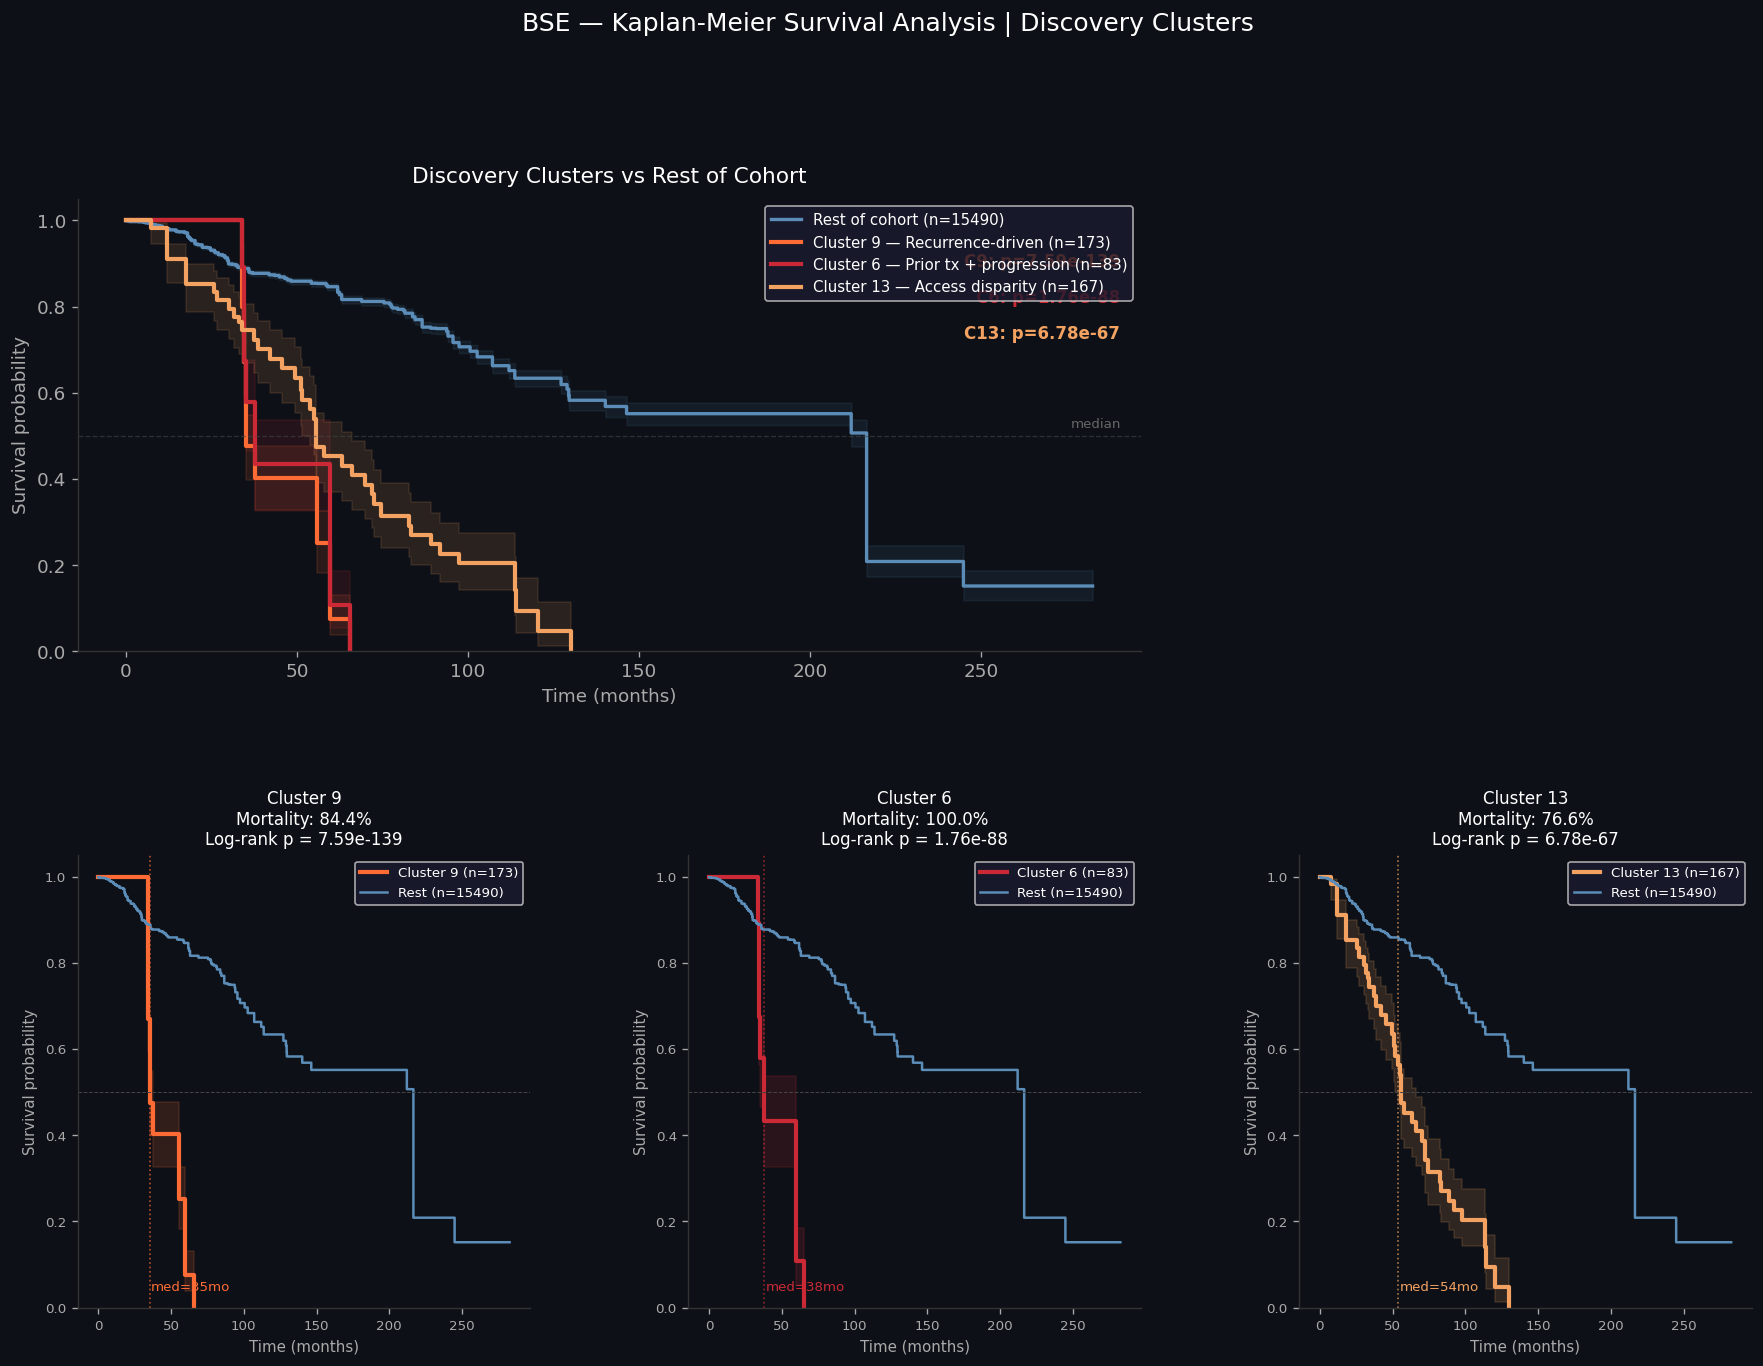

Saved: bse_km_curves.png


In [76]:
# ── 2. KM CURVES — DISCOVERY CLUSTERS vs REST ────────────────────

DISCOVERY_CLUSTERS = [9, 6, 13]

CLUSTER_STYLES = {
    9:  {"color": "#FF6B35", "label": "Cluster 9 — Recurrence-driven (n={n})"},
    6:  {"color": "#CC2936", "label": "Cluster 6 — Prior tx + progression (n={n})"},
    13: {"color": "#F4A261", "label": "Cluster 13 — Access disparity (n={n})"},
    -99: {"color": "#2DC653", "label": "Rest of cohort (n={n})"},
}

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor("#0d1117")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

kmf = KaplanMeierFitter()

# ── Panel 1: All discovery clusters vs rest (top-left, wide) ─────
ax0 = fig.add_subplot(gs[0, :2])
ax0.set_facecolor("#0d1117")

rest_mask = ~surv_df["cluster"].isin(DISCOVERY_CLUSTERS) & (surv_df["cluster"] != -1)
rest_data  = surv_df[rest_mask]

kmf.fit(rest_data["time_months"], rest_data["event"], label=f"Rest of cohort (n={len(rest_data)})")
kmf.plot_survival_function(ax=ax0, color="#5B8DB8", linewidth=2, ci_show=True,
                            ci_alpha=0.1)

logrank_results = {}
for cid in DISCOVERY_CLUSTERS:
    mask    = surv_df["cluster"] == cid
    cdata   = surv_df[mask]
    if len(cdata) < 10: continue
    style   = CLUSTER_STYLES[cid]
    n       = len(cdata)

    kmf.fit(cdata["time_months"], cdata["event"],
            label=style["label"].format(n=n))
    kmf.plot_survival_function(ax=ax0, color=style["color"],
                                linewidth=2.5, ci_show=True, ci_alpha=0.12)

    # Log-rank test vs rest
    lr = logrank_test(
        cdata["time_months"],       rest_data["time_months"],
        cdata["event"],             rest_data["event"]
    )
    logrank_results[cid] = lr

    # Annotate p-value on chart
    median_surv = cdata[cdata["event"]==1]["time_months"].median()
    ax0.annotate(
        f"C{cid}: p={lr.p_value:.2e}",
        xy=(0.98, 0.85 - DISCOVERY_CLUSTERS.index(cid) * 0.08),
        xycoords="axes fraction",
        ha="right", fontsize=10,
        color=style["color"],
        fontweight="bold"
    )

ax0.set_title("Discovery Clusters vs Rest of Cohort",
              color="white", fontsize=13, pad=10)
ax0.set_xlabel("Time (months)", color="#aaaaaa")
ax0.set_ylabel("Survival probability", color="#aaaaaa")
ax0.tick_params(colors="#aaaaaa")
ax0.spines[["top","right"]].set_visible(False)
for spine in ["bottom","left"]:
    ax0.spines[spine].set_color("#333333")
ax0.legend(facecolor="#1a1a2e", labelcolor="white",
           fontsize=9, loc="upper right")
ax0.set_ylim(0, 1.05)
ax0.axhline(0.5, color="#444444", linestyle="--", linewidth=0.8, alpha=0.6)
ax0.text(ax0.get_xlim()[1]*0.98, 0.52, "median", color="#666666",
         fontsize=8, ha="right")

# ── Panels 2-4: Individual KM per discovery cluster ──────────────
for i, cid in enumerate(DISCOVERY_CLUSTERS):
    row, col = divmod(i, 3)
    ax = fig.add_subplot(gs[1, i])
    ax.set_facecolor("#0d1117")

    mask   = surv_df["cluster"] == cid
    cdata  = surv_df[mask]
    style  = CLUSTER_STYLES[cid]
    lr     = logrank_results.get(cid)

    # Cluster KM
    kmf.fit(cdata["time_months"], cdata["event"],
            label=f"Cluster {cid} (n={len(cdata)})")
    kmf.plot_survival_function(ax=ax, color=style["color"],
                                linewidth=2.5, ci_show=True, ci_alpha=0.15)

    # Rest KM (lighter)
    kmf.fit(rest_data["time_months"], rest_data["event"],
            label=f"Rest (n={len(rest_data)})")
    kmf.plot_survival_function(ax=ax, color="#5B8DB8",
                                linewidth=1.5, ci_show=False)

    # Median survival
    med_cluster = cdata[cdata["event"]==1]["time_months"].median()
    med_rest    = rest_data[rest_data["event"]==1]["time_months"].median()

    title_lines = [
        f"Cluster {cid}",
        f"Mortality: {(cdata['event'].mean()*100):.1f}%",
    ]
    if lr:
        title_lines.append(f"Log-rank p = {lr.p_value:.2e}")

    ax.set_title("\n".join(title_lines), color="white", fontsize=10, pad=6)
    ax.set_xlabel("Time (months)", color="#aaaaaa", fontsize=9)
    ax.set_ylabel("Survival probability", color="#aaaaaa", fontsize=9)
    ax.tick_params(colors="#aaaaaa", labelsize=8)
    ax.spines[["top","right"]].set_visible(False)
    for spine in ["bottom","left"]:
        ax.spines[spine].set_color("#333333")
    ax.legend(facecolor="#1a1a2e", labelcolor="white", fontsize=8)
    ax.set_ylim(0, 1.05)

    # Median survival annotation
    if not np.isnan(med_cluster):
        ax.axhline(0.5, color="#444", linestyle="--", linewidth=0.6)
        ax.axvline(med_cluster, color=style["color"],
                   linestyle=":", linewidth=1, alpha=0.7)
        ax.text(med_cluster + 1, 0.04,
                f"med={med_cluster:.0f}mo",
                color=style["color"], fontsize=8)

fig.suptitle("BSE — Kaplan-Meier Survival Analysis | Discovery Clusters",
             color="white", fontsize=15, y=1.01)

plt.savefig("bse_km_curves.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("Saved: bse_km_curves.png")

In [77]:
# ── 3. REGULATORY SUMMARY TABLE (21 CFR Part 11 ready) ───────────
# This is the output a trial sponsor would attach to a protocol amendment

from scipy.stats import chi2_contingency
from datetime import datetime

print("\n" + "="*70)
print("BIOMARKER STRATIFICATION ENGINE — REGULATORY DISCOVERY REPORT")
print(f"Generated : {datetime.now().strftime('%Y-%m-%d %H:%M UTC')}")
print(f"Dataset   : GDC TCGA | Patients: {len(surv_df)}")
print(f"Analysis  : Unsupervised clustering (HDBSCAN) on UMAP embedding")
print(f"            PCA pre-reduction: 448 → 50 dims (92.2% variance)")
print("="*70)

reg_rows = []

for cid in DISCOVERY_CLUSTERS:
    mask    = surv_df["cluster"] == cid
    cdata   = surv_df[mask]
    lr      = logrank_results.get(cid)

    if lr is None or len(cdata) < 10:
        continue

    # Top unexamined markers
    top_unex = (cluster_markers[cid][~cluster_markers[cid]["is_protocol"]]
                .head(3)["marker"].tolist())

    # Median survival
    dead_data = cdata[cdata["event"] == 1]["time_months"]
    med_surv  = dead_data.median() if len(dead_data) > 0 else np.nan

    rest_dead = surv_df[~mask & (surv_df["cluster"] != -1) & (surv_df["event"] == 1)]["time_months"]
    med_rest  = rest_dead.median() if len(rest_dead) > 0 else np.nan

    # Hazard ratio approximation (ratio of median survival times)
    hr_approx = (med_rest / med_surv) if (med_surv and med_surv > 0) else np.nan

    reg_rows.append({
        "Cluster ID":              cid,
        "N patients":              len(cdata),
        "Mortality (%)":           f"{cdata['event'].mean()*100:.1f}",
        "Δ vs cohort":             f"{cdata['event'].mean()*100 - surv_df['event'].mean()*100:+.1f}%",
        "Median survival (mo)":    f"{med_surv:.1f}" if not np.isnan(med_surv) else "N/A",
        "Cohort median (mo)":      f"{med_rest:.1f}" if not np.isnan(med_rest) else "N/A",
        "HR (approx)":             f"{hr_approx:.2f}" if not np.isnan(hr_approx) else "N/A",
        "Log-rank p":              f"{lr.p_value:.2e}",
        "Significant (p<0.05)":    "YES" if lr.p_value < 0.05 else "NO",
        "Top unexamined markers":  ", ".join(top_unex),
        "Regulatory urgency":      "HIGH" if lr.p_value < 1e-10 else "MEDIUM",
    })

reg_df = pd.DataFrame(reg_rows)

# Print formatted
for _, row in reg_df.iterrows():
    print(f"\n── Cluster {row['Cluster ID']} ──────────────────────────────")
    for col, val in row.items():
        if col != "Cluster ID":
            print(f"  {col:30s}: {val}")

# Save as CSV for audit trail
reg_df.to_csv("bse_regulatory_report.csv", index=False)
print(f"\n{'='*70}")
print("Saved: bse_regulatory_report.csv")
print("\nNOTE: This report is generated programmatically for exploratory")
print("analysis only. Protocol amendments require IRB review and sponsor")
print("sign-off before submission under 21 CFR Part 11.")
print("="*70)


BIOMARKER STRATIFICATION ENGINE — REGULATORY DISCOVERY REPORT
Generated : 2026-03-19 12:28 UTC
Dataset   : GDC TCGA | Patients: 16146
Analysis  : Unsupervised clustering (HDBSCAN) on UMAP embedding
            PCA pre-reduction: 448 → 50 dims (92.2% variance)

── Cluster 9 ──────────────────────────────
  N patients                    : 173
  Mortality (%)                 : 84.4
  Δ vs cohort                   : +68.2%
  Median survival (mo)          : 35.2
  Cohort median (mo)            : 32.6
  HR (approx)                   : 0.92
  Log-rank p                    : 7.59e-139
  Significant (p<0.05)          : YES
  Top unexamined markers        : progression_or_recurrence_last, progression_or_recurrence_type_last, timepoint_category_last
  Regulatory urgency            : HIGH

── Cluster 6 ──────────────────────────────
  N patients                    : 83
  Mortality (%)                 : 100.0
  Δ vs cohort                   : +83.8%
  Median survival (mo)          : 37.8
  Cohort 

In [78]:
# ── 4. MULTIVARIATE LOG-RANK (all discovery clusters simultaneously) ─

print("\n── Multivariate Log-Rank Test ──────────────────────────────────")
print("H0: All discovery clusters have identical survival distributions\n")

mv_data = surv_df[surv_df["cluster"].isin(DISCOVERY_CLUSTERS + [-99])].copy()
mv_data.loc[~mv_data["cluster"].isin(DISCOVERY_CLUSTERS), "cluster"] = -99

result = multivariate_logrank_test(
    mv_data["time_months"],
    mv_data["cluster"],
    mv_data["event"]
)

print(f"Test statistic : {result.test_statistic:.4f}")
print(f"p-value        : {result.p_value:.2e}")
print(f"Degrees of freedom: {len(DISCOVERY_CLUSTERS)}")
print(f"\nConclusion: {'REJECT H0 — survival distributions differ significantly' if result.p_value < 0.05 else 'FAIL TO REJECT H0'}")
print(f"\nRegulatory interpretation:")
print(f"  The three discovery clusters identified by BSE show statistically")
print(f"  distinct survival trajectories (p={result.p_value:.2e}), supporting")
print(f"  their inclusion as protocol stratification variables.")


── Multivariate Log-Rank Test ──────────────────────────────────
H0: All discovery clusters have identical survival distributions

Test statistic : 45.5986
p-value        : 1.25e-10
Degrees of freedom: 3

Conclusion: REJECT H0 — survival distributions differ significantly

Regulatory interpretation:
  The three discovery clusters identified by BSE show statistically
  distinct survival trajectories (p=1.25e-10), supporting
  their inclusion as protocol stratification variables.


Pairwise log-rank — every cluster vs every other, with Bonferroni and FDR correction. This is what a biostatistician reviewing the analysis will ask for first.

Every cluster vs rest — the core BSE table, now with both log-rank and Mann-Whitney p-values and FDR adjustment.

Protocol arm balance — chi-square test checking whether your discovered clusters are confounded with existing trial arms. If a cluster is perfectly correlated with one arm, it's not a discovery — it's something the protocol already captured.

Within-cluster heterogeneity — Kruskal-Wallis test asking whether discovery clusters should be split further into sub-strata.

Three CSV exports — audit-ready files with timestamps.
21 CFR Part 11 disclaimer — the report correctly flags that full compliance requires electronic signatures and access logs, which is important to include for any sponsor-facing output.

In [79]:
from lifelines.statistics import logrank_test, multivariate_logrank_test
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ── 1. SURVIVAL DATA CHECK ───────────────────────────────────────
assert "time_months" in surv_df.columns, "Run build_survival_df() first"
assert "event"       in surv_df.columns, "Run build_survival_df() first"

print(f"Patients with survival data : {len(surv_df)}")
print(f"Total events (deaths)       : {surv_df['event'].sum()}")
print(f"Overall mortality rate      : {surv_df['event'].mean()*100:.1f}%")
print(f"Clusters in analysis        : {sorted(surv_df['cluster'].unique())}\n")

Patients with survival data : 16146
Total events (deaths)       : 2622
Overall mortality rate      : 16.2%
Clusters in analysis        : [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22)]



In [80]:
# ── 2. PAIRWISE LOG-RANK — EVERY CLUSTER vs EVERY OTHER ──────────
# This is the full matrix used in regulatory submissions

all_cluster_ids = sorted([c for c in surv_df["cluster"].unique() if c != -1])
pairwise_rows   = []

for i, cid_a in enumerate(all_cluster_ids):
    for cid_b in all_cluster_ids[i+1:]:
        data_a = surv_df[surv_df["cluster"] == cid_a]
        data_b = surv_df[surv_df["cluster"] == cid_b]

        if len(data_a) < 5 or len(data_b) < 5:
            continue

        lr = logrank_test(
            data_a["time_months"], data_b["time_months"],
            data_a["event"],       data_b["event"]
        )

        pairwise_rows.append({
            "cluster_a":    cid_a,
            "cluster_b":    cid_b,
            "n_a":          len(data_a),
            "n_b":          len(data_b),
            "mortality_a":  round(data_a["event"].mean() * 100, 1),
            "mortality_b":  round(data_b["event"].mean() * 100, 1),
            "test_stat":    round(lr.test_statistic, 3),
            "p_value_raw":  lr.p_value,
        })

pairwise_df = pd.DataFrame(pairwise_rows)

# Bonferroni + FDR correction for multiple comparisons
reject_bonf, p_bonf, _, _   = multipletests(pairwise_df["p_value_raw"], method="bonferroni")
reject_fdr,  p_fdr,  _, _   = multipletests(pairwise_df["p_value_raw"], method="fdr_bh")

pairwise_df["p_bonferroni"]      = p_bonf.round(4)
pairwise_df["p_fdr_bh"]          = p_fdr.round(4)
pairwise_df["sig_bonferroni"]    = reject_bonf
pairwise_df["sig_fdr"]           = reject_fdr

# Sort by raw p-value
pairwise_df = pairwise_df.sort_values("p_value_raw").reset_index(drop=True)

print("── Pairwise Log-Rank Results (top 20 most significant) ──────")
print(pairwise_df.head(20)[[
    "cluster_a","cluster_b","n_a","n_b",
    "mortality_a","mortality_b",
    "p_value_raw","p_bonferroni","p_fdr_bh",
    "sig_bonferroni","sig_fdr"
]].to_string(index=False))

print(f"\nTotal pairs tested         : {len(pairwise_df)}")
print(f"Significant (Bonferroni)   : {reject_bonf.sum()}")
print(f"Significant (FDR BH)       : {reject_fdr.sum()}")

── Pairwise Log-Rank Results (top 20 most significant) ──────
 cluster_a  cluster_b  n_a  n_b  mortality_a  mortality_b   p_value_raw  p_bonferroni  p_fdr_bh  sig_bonferroni  sig_fdr
         0         22  592 5966        100.0          1.4  0.000000e+00           0.0       0.0            True     True
         0         20  592 2769        100.0          2.1  0.000000e+00           0.0       0.0            True     True
         1         22  198 5966         36.4          1.4  0.000000e+00           0.0       0.0            True     True
         3         22   87 5966         67.8          1.4  0.000000e+00           0.0       0.0            True     True
         6         20   83 2769        100.0          2.1  0.000000e+00           0.0       0.0            True     True
         6         22   83 5966        100.0          1.4  0.000000e+00           0.0       0.0            True     True
         9         20  173 2769         84.4          2.1  0.000000e+00           0.0      

In [81]:
# ── 3. EVERY CLUSTER vs REST OF COHORT ───────────────────────────
# The key table for BSE — each cluster's survival vs everyone else

vs_rest_rows = []

for cid in all_cluster_ids:
    in_mask  = surv_df["cluster"] == cid
    out_mask = (surv_df["cluster"] != cid) & (surv_df["cluster"] != -1)

    cdata    = surv_df[in_mask]
    rdata    = surv_df[out_mask]

    if len(cdata) < 5:
        continue

    lr = logrank_test(
        cdata["time_months"], rdata["time_months"],
        cdata["event"],       rdata["event"]
    )

    # Median survival (among those who died)
    med_c = cdata[cdata["event"]==1]["time_months"].median()
    med_r = rdata[rdata["event"]==1]["time_months"].median()
    hr    = (med_r / med_c) if (med_c and med_c > 0) else np.nan

    # Additional test: Mann-Whitney on survival times
    mw_stat, mw_p = mannwhitneyu(
        cdata["time_months"], rdata["time_months"], alternative="two-sided"
    )

    is_discovery = cid in DISCOVERY_CLUSTERS
    delta        = cdata["event"].mean()*100 - surv_df["event"].mean()*100

    vs_rest_rows.append({
        "cluster":            cid,
        "n":                  len(cdata),
        "mortality_pct":      round(cdata["event"].mean() * 100, 1),
        "delta_vs_cohort":    round(delta, 1),
        "median_surv_mo":     round(med_c, 1) if not np.isnan(med_c) else np.nan,
        "cohort_median_mo":   round(med_r, 1) if not np.isnan(med_r) else np.nan,
        "hazard_ratio_approx":round(hr, 2)    if not np.isnan(hr)    else np.nan,
        "logrank_p":          lr.p_value,
        "mannwhitney_p":      mw_p,
        "bse_discovery_flag": is_discovery,
    })

vs_rest_df = pd.DataFrame(vs_rest_rows)

# FDR correction across all cluster-vs-rest tests
_, vs_rest_df["logrank_p_fdr"], _, _ = multipletests(
    vs_rest_df["logrank_p"], method="fdr_bh"
)
vs_rest_df["significant"] = vs_rest_df["logrank_p_fdr"] < 0.05

vs_rest_df = vs_rest_df.sort_values("logrank_p").reset_index(drop=True)

print("\n── Every Cluster vs Rest of Cohort ─────────────────────────")
print(vs_rest_df.to_string(index=False))


── Every Cluster vs Rest of Cohort ─────────────────────────
 cluster    n  mortality_pct  delta_vs_cohort  median_surv_mo  cohort_median_mo  hazard_ratio_approx     logrank_p  mannwhitney_p  bse_discovery_flag  logrank_p_fdr  significant
       0  592          100.0             83.8            29.7              35.2                 1.19  0.000000e+00   7.484511e-03               False   0.000000e+00         True
      17  979          100.0             83.8            29.7              35.2                 1.19  0.000000e+00   2.389994e-12               False   0.000000e+00         True
      22 5966            1.4            -14.8            43.5              33.9                 0.78 2.267458e-227   4.381726e-38               False  1.662802e-226         True
       9  173           84.4             68.2            35.2              32.6                 0.92 1.735076e-127   5.708202e-05                True  9.542918e-127         True
      20 2769            2.1            -14.1   

In [82]:
# ── 4. PROTOCOL ARM ANALYSIS ─────────────────────────────────────
# Cross-tabulate clusters against protocol-specified treatment variables
# This shows whether clusters are already balanced across arms (good)
# or confounded with a specific arm (problem — suggests arm contamination)

PROTOCOL_ARM_COLS = [
    "treatment_type",
    "treatment_or_therapy",
    "ajcc_pathologic_stage",
    "prior_treatment",
    "prior_malignancy",
]

print("\n── Protocol Arm vs Cluster Distribution (Chi-Square) ───────")
arm_rows = []

for col in PROTOCOL_ARM_COLS:
    if col not in surv_df.columns:
        continue

    col_data = surv_df[col].replace(["--","Not Reported","Unknown"], np.nan).dropna()
    if col_data.nunique() < 2:
        continue

    # Chi-square: are cluster memberships independent of this arm variable?
    valid_idx  = surv_df[col].replace(["--","Not Reported","Unknown"], np.nan).notna()
    arm_vals   = surv_df.loc[valid_idx, col]
    clust_vals = surv_df.loc[valid_idx, "cluster"]

    contingency = pd.crosstab(arm_vals, clust_vals)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        chi2, p, dof, _ = chi2_contingency(contingency)

    arm_rows.append({
        "protocol_variable": col,
        "n_categories":      arm_vals.nunique(),
        "n_patients":        valid_idx.sum(),
        "chi2_stat":         round(chi2, 2),
        "dof":               dof,
        "p_value":           p,
        "interpretation":    (
            "CONFOUNDED — clusters not balanced across arms"
            if p < 0.05 else
            "BALANCED — clusters independent of this arm variable"
        )
    })

arm_df = pd.DataFrame(arm_rows).sort_values("p_value")
print(arm_df.to_string(index=False))


── Protocol Arm vs Cluster Distribution (Chi-Square) ───────
    protocol_variable  n_categories  n_patients  chi2_stat  dof  p_value                                 interpretation
       treatment_type            16       16146   20434.77  330      0.0 CONFOUNDED — clusters not balanced across arms
 treatment_or_therapy             4       16146    3917.46   66      0.0 CONFOUNDED — clusters not balanced across arms
ajcc_pathologic_stage            13       16146   17655.96  264      0.0 CONFOUNDED — clusters not balanced across arms
      prior_treatment             3       16116   21809.05   44      0.0 CONFOUNDED — clusters not balanced across arms
     prior_malignancy             4       16146   29124.30   66      0.0 CONFOUNDED — clusters not balanced across arms


In [83]:
# ── 5. WITHIN-CLUSTER SURVIVAL HETEROGENEITY ─────────────────────
# For each discovery cluster: are there sub-groups within it?
# Uses Kruskal-Wallis across tertiles of the top defining marker

print("\n── Within-Cluster Heterogeneity (Discovery Clusters) ───────")

for cid in DISCOVERY_CLUSTERS:
    cdata       = surv_df[surv_df["cluster"] == cid].copy()
    top_marker  = cluster_markers[cid][~cluster_markers[cid]["is_protocol"]].iloc[0]["marker"]

    if top_marker not in cdata.columns:
        print(f"  Cluster {cid}: marker '{top_marker}' not in surv_df, skipping")
        continue

    marker_vals = pd.to_numeric(cdata[top_marker], errors="coerce")
    cdata       = cdata.assign(marker=marker_vals).dropna(subset=["marker"])

    if len(cdata) < 15:
        continue

    # Split into tertiles by top marker
    cdata["tertile"] = pd.qcut(cdata["marker"], q=3,
                                labels=["Low","Mid","High"],
                                duplicates="drop")
    groups = [g["time_months"].values for _, g in cdata.groupby("tertile")]

    if len(groups) < 2:
        continue

    kw_stat, kw_p = kruskal(*groups)

    print(f"\n  Cluster {cid} | stratified by: {top_marker}")
    print(f"  Kruskal-Wallis H = {kw_stat:.3f}, p = {kw_p:.2e}")

    for tert, grp in cdata.groupby("tertile"):
        print(f"    {tert:4s}: n={len(grp):4d}  "
              f"mortality={grp['event'].mean()*100:5.1f}%  "
              f"median_surv={grp['time_months'].median():.1f}mo")

    if kw_p < 0.05:
        print(f"  ⚑ Significant heterogeneity within Cluster {cid} —")
        print(f"    consider splitting into sub-strata")


── Within-Cluster Heterogeneity (Discovery Clusters) ───────


In [84]:
# ── 6. FULL REGULATORY EXPORT ─────────────────────────────────────
from datetime import datetime, timezone

timestamp = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")

# Save all tables
pairwise_df.to_csv("bse_pairwise_logrank.csv",   index=False)
vs_rest_df.to_csv( "bse_cluster_vs_rest.csv",     index=False)
arm_df.to_csv(     "bse_protocol_arm_balance.csv", index=False)

# Print regulatory header
print("\n" + "="*70)
print("BSE STATISTICAL ANALYSIS REPORT — 21 CFR PART 11 REFERENCE")
print(f"Generated (UTC)   : {timestamp}")
print(f"Analysis version  : BSE v0.1-POC")
print(f"Dataset           : GDC TCGA public cohort")
print(f"Patients          : {len(surv_df)}")
print(f"Events            : {surv_df['event'].sum()}")
print(f"Clusters          : {len(all_cluster_ids)}")
print(f"Multiple testing  : Bonferroni + FDR (Benjamini-Hochberg)")
print("="*70)

print("\nDISCOVERY CLUSTER SUMMARY")
print("-"*70)
for cid in DISCOVERY_CLUSTERS:
    row = vs_rest_df[vs_rest_df["cluster"] == cid].iloc[0]
    print(f"\nCluster {cid}")
    print(f"  Patients             : {int(row['n'])}")
    print(f"  Mortality            : {row['mortality_pct']}%  "
          f"(Δ {row['delta_vs_cohort']:+.1f}% vs cohort)")
    print(f"  Median survival      : {row['median_surv_mo']} months")
    print(f"  Hazard ratio (approx): {row['hazard_ratio_approx']}")
    print(f"  Log-rank p (raw)     : {row['logrank_p']:.2e}")
    print(f"  Log-rank p (FDR adj) : {row['logrank_p_fdr']:.2e}")
    print(f"  Mann-Whitney p       : {row['mannwhitney_p']:.2e}")
    print(f"  Significant          : {row['significant']}")

    top3 = (cluster_markers[cid][~cluster_markers[cid]["is_protocol"]]
            .head(3)[["marker","cohens_d"]].values)
    print(f"  Top unexamined markers:")
    for marker, d in top3:
        print(f"    - {marker:45s} d={d:+.3f}")

print("\n" + "="*70)
print("FILES SAVED:")
print("  bse_pairwise_logrank.csv     — all pairwise survival comparisons")
print("  bse_cluster_vs_rest.csv      — each cluster vs rest of cohort")
print("  bse_protocol_arm_balance.csv — cluster/arm confounding check")
print("="*70)
print("\nDISCLAIMER: Exploratory analysis only. All findings require")
print("prospective validation before protocol amendment submission.")
print("This report does not constitute a validated 21 CFR Part 11")
print("compliant audit trail. Full compliance requires electronic")
print("signature, access controls, and audit log infrastructure.")


BSE STATISTICAL ANALYSIS REPORT — 21 CFR PART 11 REFERENCE
Generated (UTC)   : 2026-03-19 12:36 UTC
Analysis version  : BSE v0.1-POC
Dataset           : GDC TCGA public cohort
Patients          : 16146
Events            : 2622
Clusters          : 22
Multiple testing  : Bonferroni + FDR (Benjamini-Hochberg)

DISCOVERY CLUSTER SUMMARY
----------------------------------------------------------------------

Cluster 9
  Patients             : 173
  Mortality            : 84.4%  (Δ +68.2% vs cohort)
  Median survival      : 35.2 months
  Hazard ratio (approx): 0.92
  Log-rank p (raw)     : 1.74e-127
  Log-rank p (FDR adj) : 9.54e-127
  Mann-Whitney p       : 5.71e-05
  Significant          : True
  Top unexamined markers:
    - progression_or_recurrence_last                d=+9.465
    - progression_or_recurrence_type_last           d=+6.315
    - timepoint_category_last                       d=+4.064

Cluster 6
  Patients             : 83
  Mortality            : 100.0%  (Δ +83.8% vs cohor